1. 制作数据集
2. 构建模型、定义损失函数、定义优化器、定义训练函数
3. 模型训练
4. 评估、参数调整

In [1]:
# 首先导入包
import torch
import torch.nn as nn
import pandas as pd
import numpy as np
import torchvision
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import os
import matplotlib.pyplot as plt
import torchvision.models as models
import torchmetrics
import matplotlib
# This is for the progress bar.
from tqdm import tqdm
import seaborn as sns


import logging

# 配置日志（级别、格式、输出位置）
logging.basicConfig(
    level=logging.ERROR,  # 日志级别：DEBUG < INFO < WARNING < ERROR < CRITICAL
    format="%(asctime)s - %(levelname)s - %(message)s",  # 日志格式
    # handlers=[
    #     logging.FileHandler("app.log"),  # 输出到文件
    #     logging.StreamHandler(),  # 同时输出到控制台
    # ],
)

# 记录不同级别的日志
logging.debug("这是调试信息（级别最低，默认不显示）")
logging.info("程序正常运行")
logging.warning("注意：可能存在风险")
logging.error("出错了！")
logging.critical("严重错误，程序可能崩溃")

2025-08-03 23:08:14,880 - ERROR - 出错了！
2025-08-03 23:08:14,880 - CRITICAL - 严重错误，程序可能崩溃


制作数据集

In [2]:
# 看看label文件长啥样
abs_path = os.path.abspath("./classify-leaves.ipynb")
print(abs_path)


# data/classify-leaves
data_dir = abs_path.split("实战")[0] + "data/classify-leaves/"
print(data_dir)

labels_dataframe = pd.read_csv(data_dir + "train.csv")
print(labels_dataframe.shape)
print(labels_dataframe.info())
print(labels_dataframe.describe())
print(labels_dataframe.head(5))


# 把label文件排个序
# 统计每个标签的出现次数，并按次数降序排列
label_counts = labels_dataframe["label"].value_counts()
# 提取排序后的标签列表（按出现次数从多到少）
leaves_labels = label_counts.index.tolist()
n_classes = len(leaves_labels)
print(n_classes)
print(leaves_labels[:10])
# 把label转成对应的数字
class_to_num = dict(zip(leaves_labels, range(n_classes)))
class_to_num
# 再转换回来，方便最后预测的时候使用
num_to_class = {v: k for k, v in class_to_num.items()}

/mnt/storage/Jagger/src/d2l-zh-pytorch-colab/实战/c2/classify-leaves.ipynb
/mnt/storage/Jagger/src/d2l-zh-pytorch-colab/data/classify-leaves/
(18353, 2)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18353 entries, 0 to 18352
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   image   18353 non-null  object
 1   label   18353 non-null  object
dtypes: object(2)
memory usage: 286.9+ KB
None
               image             label
count          18353             18353
unique         18353               176
top     images/0.jpg  maclura_pomifera
freq               1               353
          image             label
0  images/0.jpg  maclura_pomifera
1  images/1.jpg  maclura_pomifera
2  images/2.jpg  maclura_pomifera
3  images/3.jpg  maclura_pomifera
4  images/4.jpg  maclura_pomifera
176
['maclura_pomifera', 'ulmus_rubra', 'prunus_virginiana', 'acer_rubrum', 'broussonettia_papyrifera', 'prunus_sargentii', 'ptelea_trifoliata', 'ulmus

In [3]:
class LeavesDataset(Dataset):
    def __init__(
        self,
        csv_path,
        file_path,
        mode="train",  # 新增 "eval" 模式用于评估
        valid_ratio=0.2,
        random_seed=42,
    ):
        """
        叶片数据集处理类，支持训练/验证/测试/评估模式

        Args:
            csv_path (string): CSV文件路径
                - 训练/验证集：需包含 "image"（文件名）和 "label"（标签）列
                - 评估集：需包含 "image" 和 "label" 列（用于计算指标）
                - 测试集：仅需 "image" 列（无标签，用于预测）
            file_path (string): 图像文件所在根目录
            mode (string): 模式：
                - "train"：训练集（带数据增强）
                - "valid"：验证集（从训练CSV中划分，无增强）
                - "eval"：评估集（独立CSV，带标签，无增强，用于最终评估）
                - "test"：测试集（独立CSV，无标签，用于预测）
            valid_ratio (float): 验证集占比（仅用于从训练CSV中划分验证集）
            random_seed (int): 随机种子（确保训练/验证划分可复现）
        """
        self.file_path = file_path
        self.mode = mode
        self.labels_df = pd.read_csv(csv_path, header=0)
        self.data_len = len(self.labels_df)

        # 检查CSV列是否符合要求
        self._check_columns()

        # 根据模式读取数据
        if mode in ["train", "valid"]:
            # 从训练CSV中划分训练/验证集
            np.random.seed(random_seed)
            shuffled_indices = np.random.permutation(self.data_len)
            train_len = int(self.data_len * (1 - valid_ratio))

            selected_indices = (
                shuffled_indices[:train_len]
                if mode == "train"
                else shuffled_indices[train_len:]
            )
            self.images = self.labels_df.iloc[selected_indices]["image"].values
            self.labels = self.labels_df.iloc[selected_indices]["label"].values

        elif mode == "eval":
            # 评估集：读取独立CSV中的所有样本（带标签）
            self.images = self.labels_df["image"].values
            self.labels = self.labels_df["label"].values

        elif mode == "test":
            # 测试集：读取独立CSV中的所有样本（无标签）
            self.images = self.labels_df["image"].values
            self.labels = (
                self.labels_df["label"].values
                if "label" in self.labels_df.columns
                else None
            )

        self.real_len = len(self.images)
        print(f"已加载 {mode} 集：{self.real_len} 个样本")

    def _check_columns(self):
        """检查CSV列是否符合当前模式的要求"""
        required = []
        if self.mode in ["train", "valid", "eval"]:
            required = ["image", "label"]  # 训练/验证/评估集需要标签
        elif self.mode == "test":
            required = ["image"]  # 测试集至少需要文件名

        missing = [col for col in required if col not in self.labels_df.columns]
        if missing:
            raise ValueError(f"{self.mode} 集CSV缺少必要列：{missing}")

    def __len__(self):
        return self.real_len

    def __getitem__(self, index):
        # 读取图像
        img_name = self.images[index]
        img_path = os.path.join(self.file_path, img_name)
        try:
            image = Image.open(img_path).convert("RGB")  # 统一转为RGB
        except Exception as e:
            logging.error(f"读取图像失败：{img_path}，错误：{e}")
            raise

        # 数据变换（训练集增强，其他模式仅标准化）
        transform = self._get_transform()
        image = transform(image)

        # 处理标签
        if self.mode in ["train", "valid", "eval"]:
            # 训练/验证/评估集：返回图像+数字标签
            label = self.labels[index]
            label = class_to_num[label]  # 假设class_to_num是类别映射字典
            return image, label
        else:  # test模式
            # 测试集：返回图像+文件名（方便输出预测结果）
            if self.labels is not None:
                # 若测试集有标签，也可返回（用于临时评估）
                label = (
                    class_to_num[self.labels[index]]
                    if self.labels[index] in class_to_num
                    else -1
                )
                return image, label, img_name
            else:
                return image, img_name

    def _get_transform(self):
        """根据模式返回对应的图像变换"""
        # 通用标准化参数（ImageNet均值和标准差）
        normalize = transforms.Normalize(
            mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]
        )

        if self.mode == "train":
            # 训练集：数据增强
            return transforms.Compose(
                [
                    # 随机裁剪并缩放（比固定Resize更能模拟不同构图）
                    transforms.RandomResizedCrop(
                        224, scale=(0.8, 1.0)
                    ),  # 从原图80%-100%区域裁剪后缩放到224x224
                    transforms.RandomHorizontalFlip(p=0.2),
                    transforms.RandomVerticalFlip(p=0.2),
                    transforms.RandomRotation(15),
                    transforms.ColorJitter(
                        brightness=0.2, contrast=0.2, saturation=0.2, hue=0.2
                    ),
                    # 随机灰度化（降低对颜色的过度依赖）
                    transforms.RandomGrayscale(p=0.1),
                    # 随机高斯模糊（模拟图像模糊场景）
                    transforms.RandomApply(
                        [transforms.GaussianBlur(kernel_size=5, sigma=(0.1, 2.0))],
                        p=0.1,
                    ),
                    transforms.ToTensor(),
                    normalize,
                ]
            )
        else:
            # 验证/评估/测试集：无增强，仅Resize和标准化
            return transforms.Compose(
                [
                    transforms.Resize((224, 224)),
                    transforms.ToTensor(),
                    normalize,
                ]
            )

In [4]:
train_path = data_dir + "train.csv"
test_path = data_dir + "test.csv"
# csv文件中已经images的路径了，因此这里只到上一级目录
img_path = data_dir

train_dataset = LeavesDataset(train_path, img_path, mode="train")
val_dataset = LeavesDataset(train_path, img_path, mode="valid")
eval_dataset = LeavesDataset(train_path, img_path, mode="eval")
test_dataset = LeavesDataset(test_path, img_path, mode="test")
# print(train_dataset)
# print(val_dataset)
# print(eval_dataset)
# print(test_dataset)

已加载 train 集：14682 个样本
已加载 valid 集：3671 个样本
已加载 eval 集：18353 个样本
已加载 test 集：8800 个样本


In [5]:
batch_size = 8
# 定义data loader
train_loader = torch.utils.data.DataLoader(
    dataset=train_dataset, batch_size=batch_size, shuffle=False, num_workers=5
)
val_loader = torch.utils.data.DataLoader(
    dataset=val_dataset, batch_size=batch_size, shuffle=False, num_workers=5
)
eval_loader = torch.utils.data.DataLoader(
    dataset=eval_dataset, batch_size=batch_size, shuffle=False, num_workers=5
)
test_loader = torch.utils.data.DataLoader(
    dataset=test_dataset, batch_size=batch_size, shuffle=False, num_workers=5
)

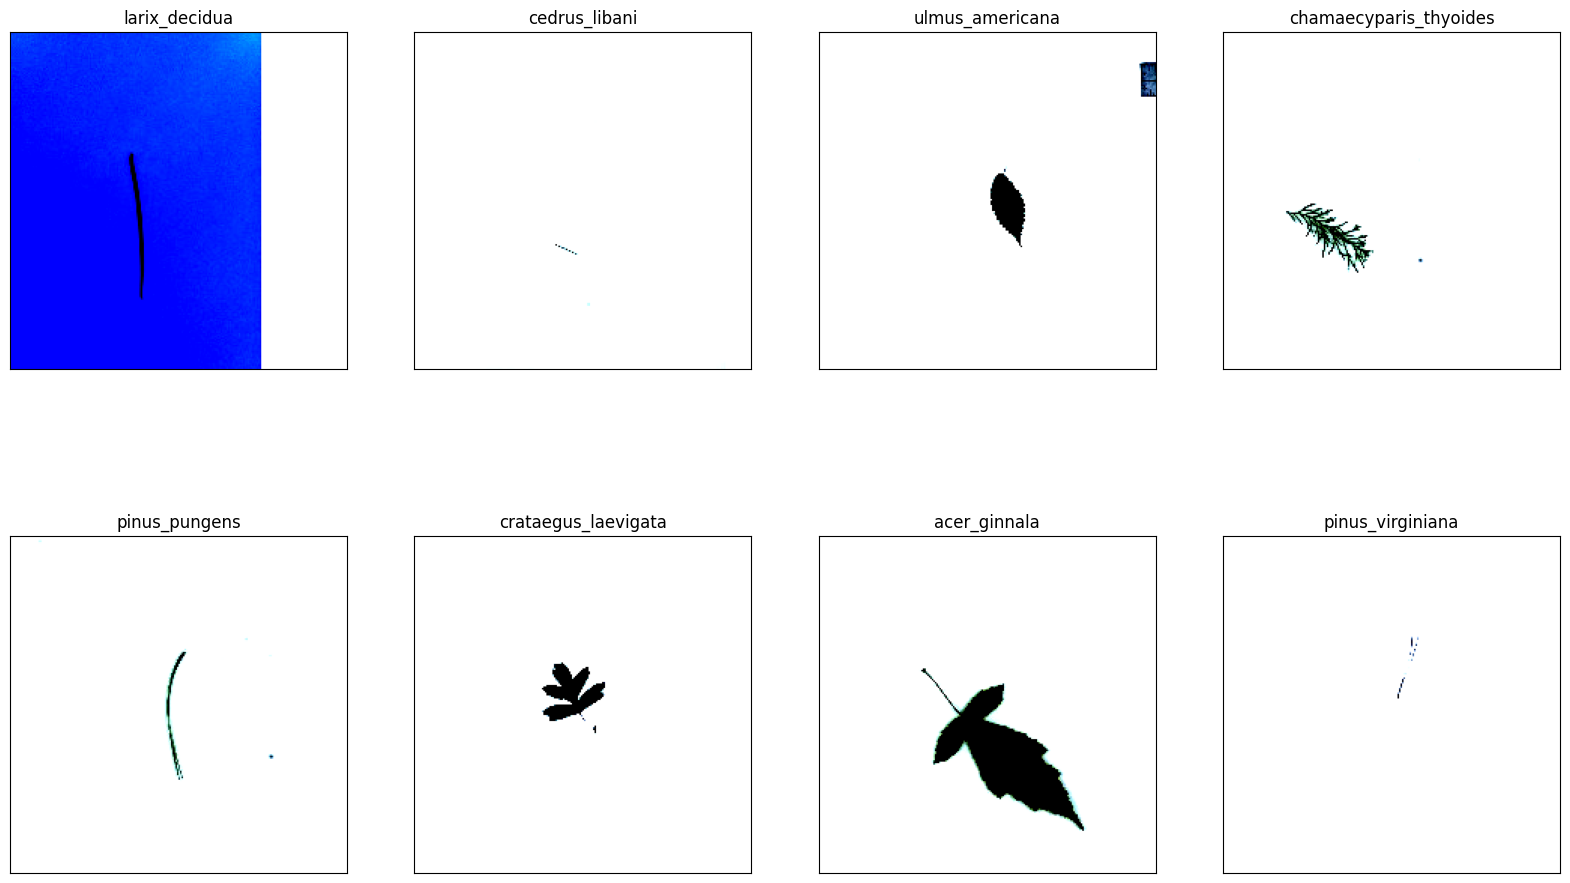

In [6]:
# 给大家展示一下数据长啥样
def im_convert(tensor):
    """展示数据"""

    image = tensor.to("cpu").clone().detach()
    image = image.numpy().squeeze()
    image = image.transpose(1, 2, 0)
    image = image.clip(0, 1)

    return image


fig = plt.figure(figsize=(20, 12))
rows = 2
columns = 4

dataiter = iter(val_loader)
inputs, classes = next(dataiter)

for idx in range(columns * rows):
    ax = fig.add_subplot(rows, columns, idx + 1, xticks=[], yticks=[])
    ax.set_title(num_to_class[int(classes[idx])])
    plt.imshow(im_convert(inputs[idx]))
plt.show()

构建模型

In [7]:
def get_net():
    num_classes = 176  # 变量名改为num_classes更规范
    net = models.resnet34(pretrained=True)

    # 修改最后一层的输出为分类数
    net.fc = nn.Linear(net.fc.in_features, num_classes)

    # 给模型添加num_classes属性，方便后续获取
    net.num_classes = num_classes  # 关键：添加类别数属性

    # 冻结非分类头的参数
    for param in net.parameters():
        param.requires_grad = False

    # 只训练分类头的参数
    for param in net.fc.parameters():
        param.requires_grad = True

    # 打印网络结构
    logging.info("Network structure:\n{}".format(net))
    return net

定义训练函数

In [8]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import CosineAnnealingLR
import logging
from tqdm import tqdm
import torchmetrics
import os
from typing import Optional, Tuple, Dict


def train(
    net: nn.Module,
    train_iter: torch.utils.data.DataLoader,
    valid_iter: torch.utils.data.DataLoader,
    num_epochs: int,
    lr: float,
    wd: float,
    devices: Tuple[torch.device],
    loss_fn: Optional[nn.Module] = None,
    model_path: str = "best_model.pth",
    patience: int = 10,  # 早停耐心值
    save_best_only: bool = True,  # 只保存最好的模型
) -> Tuple[nn.Module, Dict]:
    """
    训练模型并返回训练好的模型和训练历史

    Args:
        net: 要训练的模型
        train_iter: 训练数据加载器
        valid_iter: 验证数据加载器
        num_epochs: 训练轮数
        lr: 学习率
        wd: 权重衰减
        devices: 用于训练的设备
        loss_fn: 损失函数，如果为None则使用CrossEntropyLoss
        model_path: 模型保存路径
        patience: 早停机制的耐心值，多少轮没有提升就停止
        save_best_only: 是否只保存性能最好的模型

    Returns:
        训练好的模型和训练历史字典
    """
    # 初始化损失函数
    if loss_fn is None:
        loss_fn = nn.CrossEntropyLoss()

    # 确保保存目录存在
    os.makedirs(os.path.dirname(model_path) or ".", exist_ok=True)

    best_acc = 0.0
    counter = 0  # 早停计数器
    history = {"train_loss": [], "train_acc": [], "valid_loss": [], "valid_acc": []}

    # 数据并行处理
    net = nn.DataParallel(net, device_ids=devices).to(devices[0])

    # 优化器 - 只优化需要梯度的参数
    trainer = optim.Adam(
        (param for param in net.parameters() if param.requires_grad),
        lr=lr,
        weight_decay=wd,
    )

    # 学习率调度器
    scheduler = CosineAnnealingLR(trainer, num_epochs)

    # 初始化评估指标
    train_metrics = {
        "loss": torchmetrics.MeanMetric().to(devices[0]),
        "acc": torchmetrics.Accuracy(
            task="multiclass",
            num_classes=(
                net.module.num_classes if hasattr(net.module, "num_classes") else None
            ),
        ).to(devices[0]),
    }

    valid_metrics = {
        "loss": torchmetrics.MeanMetric().to(devices[0]),
        "acc": torchmetrics.Accuracy(
            task="multiclass",
            num_classes=(
                net.module.num_classes if hasattr(net.module, "num_classes") else None
            ),
        ).to(devices[0]),
    }

    logging.info(f"开始训练，使用设备: {devices}")
    logging.info(f"训练轮数: {num_epochs}, 初始学习率: {lr}, 权重衰减: {wd}")

    for epoch in range(num_epochs):
        # 训练阶段
        net.train()
        # 重置训练指标
        for metric in train_metrics.values():
            metric.reset()

        train_pbar = tqdm(train_iter, desc=f"Epoch {epoch + 1}/{num_epochs} [训练]")
        for X, y in train_pbar:
            X, y = X.to(devices[0], non_blocking=True), y.to(
                devices[0], non_blocking=True
            )

            # 前向传播
            y_hat = net(X)
            loss = loss_fn(y_hat, y)

            # 反向传播和优化
            trainer.zero_grad(set_to_none=True)  # 更高效的梯度清零
            loss.backward()
            trainer.step()

            # 更新指标
            train_metrics["loss"].update(loss.detach())
            train_metrics["acc"].update(y_hat.detach(), y)

            # 更新进度条
            train_pbar.set_postfix(
                {
                    "loss": f"{train_metrics['loss'].compute().item():.4f}",
                    "acc": f"{train_metrics['acc'].compute().item():.4f}",
                }
            )

        # 计算训练集指标
        train_loss = train_metrics["loss"].compute().item()
        train_acc = train_metrics["acc"].compute().item()

        # 记录训练历史
        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)

        # 打印并记录训练结果
        log_msg = f"Epoch {epoch + 1}/{num_epochs} | 训练集 | 损失: {train_loss:.4f} | 准确率: {train_acc:.4f}"
        print(log_msg)
        logging.info(log_msg)

        # 更新学习率
        scheduler.step()
        current_lr = scheduler.get_last_lr()[0]
        logging.debug(f"当前学习率: {current_lr:.6f}")

        # 验证阶段
        net.eval()
        # 重置验证指标
        for metric in valid_metrics.values():
            metric.reset()

        with torch.no_grad():
            valid_pbar = tqdm(valid_iter, desc=f"Epoch {epoch + 1}/{num_epochs} [验证]")
            for X, y in valid_pbar:
                X, y = X.to(devices[0], non_blocking=True), y.to(
                    devices[0], non_blocking=True
                )
                y_hat = net(X)
                loss = loss_fn(y_hat, y)

                # 更新指标
                valid_metrics["loss"].update(loss)
                valid_metrics["acc"].update(y_hat, y)

                # 更新进度条
                valid_pbar.set_postfix(
                    {
                        "loss": f"{valid_metrics['loss'].compute().item():.4f}",
                        "acc": f"{valid_metrics['acc'].compute().item():.4f}",
                    }
                )

        # 计算验证集指标
        valid_loss = valid_metrics["loss"].compute().item()
        valid_acc = valid_metrics["acc"].compute().item()

        # 记录验证历史
        history["valid_loss"].append(valid_loss)
        history["valid_acc"].append(valid_acc)

        # 打印并记录验证结果
        log_msg = f"Epoch {epoch + 1}/{num_epochs} | 验证集 | 损失: {valid_loss:.4f} | 准确率: {valid_acc:.4f}"
        print(log_msg)
        logging.info(log_msg)

        # 保存模型
        if valid_acc > best_acc:
            best_acc = valid_acc
            counter = 0  # 重置早停计数器
            # 保存模型
            torch.save(
                {
                    "epoch": epoch + 1,
                    "model_state_dict": net.state_dict(),
                    "optimizer_state_dict": trainer.state_dict(),
                    "scheduler_state_dict": scheduler.state_dict(),
                    "best_acc": best_acc,
                },
                model_path,
            )
            logging.info(f"保存新的最佳模型，准确率: {best_acc:.4f}")
        else:
            counter += 1
            logging.info(f"早停计数器: {counter}/{patience}")
            if counter >= patience:
                logging.info(f"早停触发，在第 {epoch + 1} 轮停止训练")
                break

        # 如果不是只保存最好模型，每轮都保存
        if not save_best_only:
            epoch_model_path = (
                f"{os.path.splitext(model_path)[0]}_epoch_{epoch + 1}.pth"
            )
            torch.save(net.state_dict(), epoch_model_path)

    # 加载最佳模型
    if os.path.exists(model_path):
        checkpoint = torch.load(model_path)
        net.load_state_dict(checkpoint["model_state_dict"])
        logging.info(f"训练结束，加载最佳模型，准确率: {checkpoint['best_acc']:.4f}")

    return net, history

In [9]:
res = train(
    net=get_net(),
    train_iter=train_loader,
    valid_iter=val_loader,
    num_epochs=10,
    lr=3e-4,
    wd=1e-3,
    devices=[
        torch.device("cuda:0") if torch.cuda.is_available() else torch.device("cpu")
    ],
    model_path="best_model.pth",
    patience=5,  # 早停耐心值
    save_best_only=True,  # 只保存最好的模型
)

/mnt/storage/Jagger/src/d2l-zh-pytorch-colab/.venv/lib/python3.11/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/mnt/storage/Jagger/src/d2l-zh-pytorch-colab/.venv/lib/python3.11/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet34_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet34_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Epoch 1/10 [训练]: 100%|██████████| 1836/1836 [02:37<00:00, 11.63it/s, loss=4.6119, acc=0.0777]


Epoch 1/10 | 训练集 | 损失: 4.6119 | 准确率: 0.0777


Epoch 1/10 [验证]: 100%|██████████| 459/459 [00:33<00:00, 13.55it/s, loss=3.8414, acc=0.1765]


Epoch 1/10 | 验证集 | 损失: 3.8414 | 准确率: 0.1765


Epoch 2/10 [训练]: 100%|██████████| 1836/1836 [00:49<00:00, 37.08it/s, loss=3.7292, acc=0.1947]


...

Epoch 9/10 | 验证集 | 损失: 2.4078 | 准确率: 0.4002


Epoch 10/10 [训练]: 100%|██████████| 1836/1836 [00:50<00:00, 36.33it/s, loss=2.5915, acc=0.4023]


Epoch 10/10 | 训练集 | 损失: 2.5915 | 准确率: 0.4023


Epoch 10/10 [验证]: 100%|██████████| 459/459 [00:12<00:00, 37.75it/s, loss=2.3675, acc=0.4146]


Epoch 10/10 | 验证集 | 损失: 2.3675 | 准确率: 0.4146


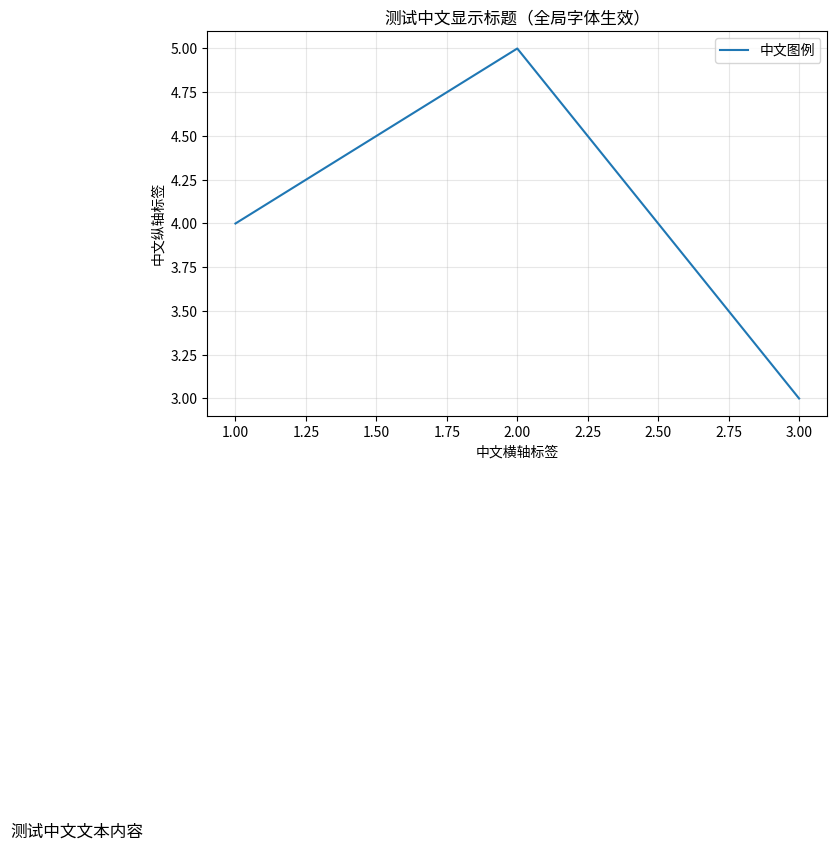

In [10]:
import torch
import torch.nn as nn
import torchmetrics
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import os
from matplotlib.gridspec import GridSpec

import matplotlib.pyplot as plt
from matplotlib.font_manager import FontProperties
import os


plt.rcParams["axes.unicode_minus"] = False  # 解决负号显示问题
# 配置支持中文的无衬线字体（优先使用Noto Sans CJK SC）
plt.rcParams["font.serif"] =["Noto Sans CJK JP"] + plt.rcParams["font.serif"]
plt.rcParams["font.sans-serif"] = ["Noto Sans CJK JP"] + plt.rcParams["font.sans-serif"]

# 测试绘图（无需再单独指定fontproperties，全局配置会生效）
plt.figure(figsize=(8, 5))
plt.title("测试中文显示标题（全局字体生效）")  # 标题
plt.xlabel("中文横轴标签")  # X轴标签
plt.ylabel("中文纵轴标签")  # Y轴标签
plt.text(0.2, 0.5, "测试中文文本内容", fontsize=12)  # 文本
plt.plot([1, 2, 3], [4, 5, 3], label="中文图例")  # 图例
plt.legend()  # 显示图例
plt.grid(alpha=0.3)  # 网格线


def evaluate_model(
    net,
    data_iter,
    device,
    num_classes,
    loss_fn=nn.CrossEntropyLoss(),
    class_names=None,
    save_figures=True,
    figures_dir="evaluation_figures",
    fig_size=(16, 14),
    top_worst=5,  # 只展示性能最差的类别数量
):
    """
    评估模型性能的通用函数，专注展示性能最差的5个类别

    参数:
        net: 要评估的模型
        data_iter: 数据迭代器
        device: 计算设备
        num_classes: 类别数量
        loss_fn: 损失函数
        class_names: 类别名称列表
        save_figures: 是否保存可视化图表
        figures_dir: 图表保存目录
        fig_size: 图表整体大小
        top_worst: 展示性能最差的类别数量（默认5个）

    返回:
        metrics: 包含各项评估指标的字典
        fig: 生成的可视化图表对象
    """
    # 创建保存目录
    if save_figures and not os.path.exists(figures_dir):
        os.makedirs(figures_dir)

    # 初始化评估指标
    loss_metric = torchmetrics.MeanMetric().to(device)
    acc_metric = torchmetrics.Accuracy(task="multiclass", num_classes=num_classes).to(
        device
    )
    precision_metric = torchmetrics.Precision(
        task="multiclass", num_classes=num_classes, average="macro"
    ).to(device)
    recall_metric = torchmetrics.Recall(
        task="multiclass", num_classes=num_classes, average="macro"
    ).to(device)
    f1_metric = torchmetrics.F1Score(
        task="multiclass", num_classes=num_classes, average="macro"
    ).to(device)

    # 每个类别的指标
    class_precision = torchmetrics.Precision(
        task="multiclass", num_classes=num_classes, average="none"
    ).to(device)
    class_recall = torchmetrics.Recall(
        task="multiclass", num_classes=num_classes, average="none"
    ).to(device)
    class_f1 = torchmetrics.F1Score(
        task="multiclass", num_classes=num_classes, average="none"
    ).to(device)

    all_preds = []
    all_labels = []

    # 评估模型
    net.eval()
    with torch.no_grad():
        for X, y in data_iter:
            X, y = X.to(device), y.to(device)
            y_hat = net(X)
            loss = loss_fn(y_hat, y)

            # 更新指标
            loss_metric.update(loss)
            acc_metric.update(y_hat, y)
            precision_metric.update(y_hat, y)
            recall_metric.update(y_hat, y)
            f1_metric.update(y_hat, y)
            class_precision.update(y_hat, y)
            class_recall.update(y_hat, y)
            class_f1.update(y_hat, y)

            # 收集预测结果和标签
            preds = torch.argmax(y_hat, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(y.cpu().numpy())

    # 计算混淆矩阵
    cm = confusion_matrix(all_labels, all_preds)

    # 准备类别名称
    if class_names is None:
        # class_names = [str(i) for i in range(num_classes)]
        class_names = [num_to_class[i] for i in range(num_classes)]

    # 计算各项指标
    loss = loss_metric.compute().item()
    accuracy = acc_metric.compute().item()
    precision = precision_metric.compute().item()
    recall = recall_metric.compute().item()
    f1 = f1_metric.compute().item()

    # 计算每个类别的指标
    class_precision_vals = class_precision.compute().cpu().numpy()
    class_recall_vals = class_recall.compute().cpu().numpy()
    class_f1_vals = class_f1.compute().cpu().numpy()

    # 整理所有评估指标
    metrics = {
        "loss": loss,
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "class_precision": dict(zip(class_names, class_precision_vals)),
        "class_recall": dict(zip(class_names, class_recall_vals)),
        "class_f1": dict(zip(class_names, class_f1_vals)),
        "confusion_matrix": cm,
        "all_preds": all_preds,
        "all_labels": all_labels,
        "classification_report": classification_report(
            all_labels, all_preds, target_names=class_names, output_dict=True
        ),
    }

    # 筛选性能最差的top_worst个类别（按F1分数排序）
    # 将类别与F1分数配对并排序
    class_f1_pairs = sorted(zip(class_names, class_f1_vals), key=lambda x: x[1])
    worst_classes = class_f1_pairs[:top_worst]  # 取F1最低的前5个
    worst_class_names = [x[0] for x in worst_classes]
    worst_class_indices = [class_names.index(name) for name in worst_class_names]

    # worst_class_names = [num_to_class[x[0]] for x in worst_classes]
    # worst_class_indices = [class_names.index(name) for name in worst_class_names]

    # 提取最差类别的指标值
    worst_f1 = [x[1] for x in worst_classes]
    worst_precision = [class_precision_vals[i] for i in worst_class_indices]
    worst_recall = [class_recall_vals[i] for i in worst_class_indices]

    # 提取最差类别的混淆矩阵子矩阵
    # 获取这些类别在原始混淆矩阵中的索引
    cm_worst = cm[worst_class_indices][:, worst_class_indices]

    # 创建可视化图表
    fig = plt.figure(figsize=fig_size)
    gs = GridSpec(2, 2, figure=fig)

    # 1. 最差类别的混淆矩阵热图
    ax1 = fig.add_subplot(gs[0, 0])
    sns.heatmap(
        cm_worst,
        annot=True,
        fmt="d",
        cmap="Reds",  # 用红色系突出最差类别
        xticklabels=worst_class_names,
        yticklabels=worst_class_names,
        ax=ax1,
        cbar_kws={"label": "样本数"},
    )
    ax1.set_xlabel("预测类别")
    ax1.set_ylabel("真实类别")
    ax1.set_title(f"性能最差的{top_worst}个类别混淆矩阵")

    # 2. 最差类别的性能雷达图
    ax2 = fig.add_subplot(gs[0, 1], polar=True)

    # 准备雷达图数据
    categories = ["精确率", "召回率", "F1分数"]
    N = len(categories)
    angles = [n / float(N) * 2 * np.pi for n in range(N)]
    angles += angles[:1]

    # 绘制每个最差类别的雷达图
    for i, class_name in enumerate(worst_class_names):
        values = [worst_precision[i], worst_recall[i], worst_f1[i]]
        values += values[:1]
        ax2.plot(angles, values, linewidth=2, linestyle="solid", label=class_name)
        ax2.fill(angles, values, alpha=0.1)

    ax2.set_xticks(angles[:-1])
    ax2.set_xticklabels(categories)
    ax2.set_ylim(0, 1.0)
    ax2.set_title(f"性能最差的{top_worst}个类别指标雷达图")
    ax2.legend(bbox_to_anchor=(1.1, 1.05))

    # 3. 整体性能指标条形图（保留整体指标作为参考）
    ax3 = fig.add_subplot(gs[1, 0])
    metrics_names = ["准确率", "精确率", "召回率", "F1分数"]
    metrics_values = [accuracy, precision, recall, f1]

    sns.barplot(x=metrics_names, y=metrics_values, ax=ax3, palette="viridis")
    ax3.set_ylim(0, 1.0)
    ax3.set_title("整体性能指标（参考）")

    # 在柱状图上添加数值标签
    for i, v in enumerate(metrics_values):
        ax3.text(i, v + 0.01, f"{v:.4f}", ha="center")

    # 4. 最差类别的F1分数条形图
    ax4 = fig.add_subplot(gs[1, 1])
    sns.barplot(x=worst_class_names, y=worst_f1, ax=ax4, palette="Reds_r")
    ax4.set_title(f"性能最差的{top_worst}个类别的F1分数")
    ax4.set_ylim(0, 1.0)

    # 在柱状图上添加数值标签
    for i, v in enumerate(worst_f1):
        ax4.text(i, v + 0.01, f"{v:.4f}", ha="center", rotation=45)

    plt.tight_layout()

    # 保存图表
    if save_figures:
        fig.savefig(
            os.path.join(figures_dir, "worst_classes_evaluation.png"),
            dpi=300,
            bbox_inches="tight",
        )
        # 单独保存最差类别的混淆矩阵
        plt.figure(figsize=(10, 8))
        sns.heatmap(
            cm_worst,
            annot=True,
            fmt="d",
            cmap="Reds",
            xticklabels=worst_class_names,
            yticklabels=worst_class_names,
            cbar_kws={"label": "样本数"},
        )
        plt.xlabel("预测类别")
        plt.ylabel("真实类别")
        plt.title(f"性能最差的{top_worst}个类别混淆矩阵")
        plt.tight_layout()
        plt.savefig(
            os.path.join(figures_dir, "worst_classes_confusion_matrix.png"),
            dpi=300,
            bbox_inches="tight",
        )
        plt.close()

    return metrics, fig

/mnt/storage/Jagger/src/d2l-zh-pytorch-colab/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/mnt/storage/Jagger/src/d2l-zh-pytorch-colab/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/mnt/storage/Jagger/src/d2l-zh-pytorch-colab/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this beha

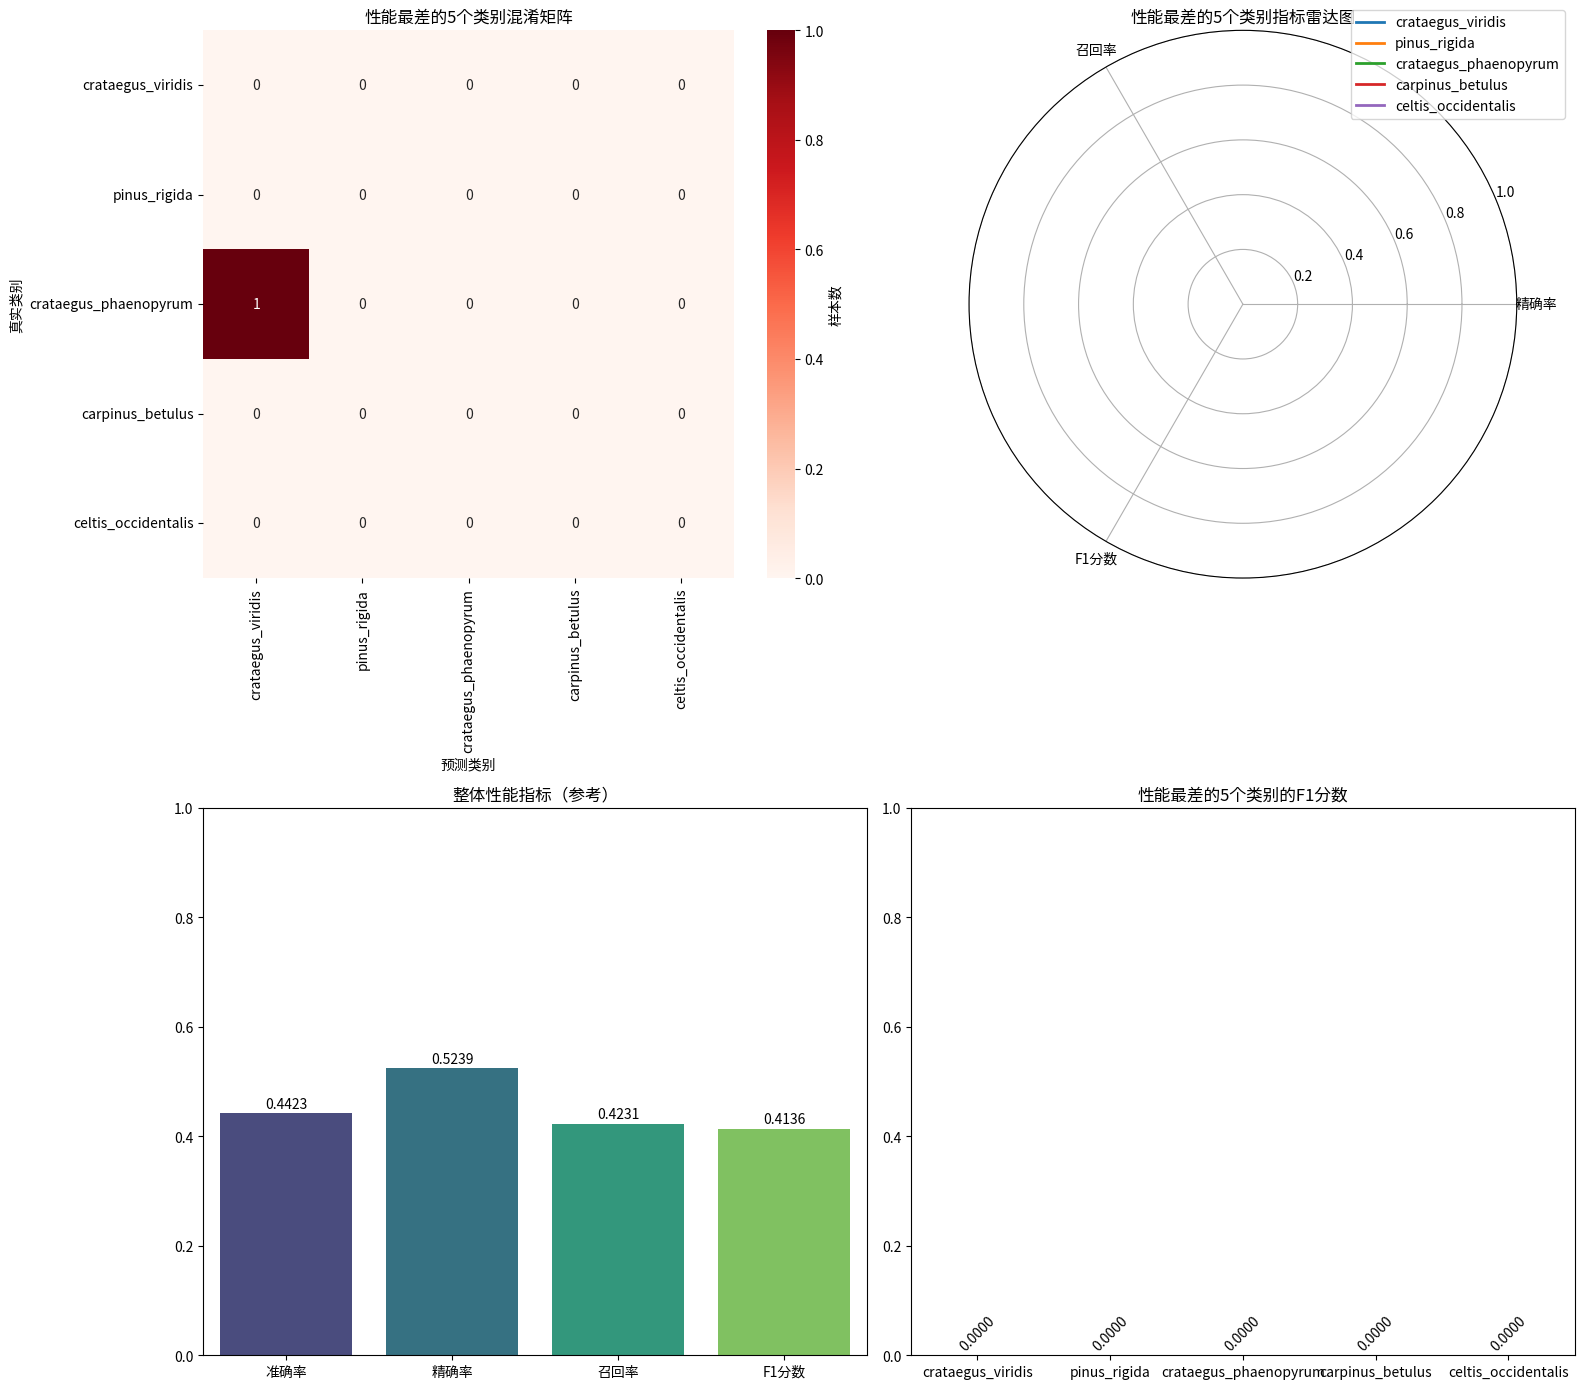

In [11]:
test_metrics, test_fig = evaluate_model(
    net=res[0],
    data_iter=eval_loader,
    device=torch.device("cuda:0") if torch.cuda.is_available() else torch.device("cpu"),
    num_classes=176,
    # class_names=class_names,
    save_figures=True,
    figures_dir="test_evaluation_results",
)

In [12]:
import matplotlib.font_manager as fm
import os
import re


def find_matplotlib_fonts(show_all=False, show_chinese_support=True):
    """
    搜寻系统中Matplotlib可用的字体文件（适配用于Matplotlib 3.8+版本）

    参数:
        show_all: 是否显示所有字体
        show_chinese_support: 是否特别标记支持中文的字体
    """
    # 获取字体管理器（新版本Matplotlib推荐方式）
    font_manager = fm.FontManager()
    # 获取所有可用字体属性
    font_properties = font_manager.ttflist

    # 用于检测中文字体的正则表达式
    # 匹配中文字符或常见中文字体名称关键词
    chinese_pattern = re.compile(
        r"[\u4e00-\u9fff]|"  # 匹配任何中文字符
        r"(Noto Sans CJK)|(WenQuanYi)|(Heiti)|(Microsoft YaHei)|"
        r"(SimHei)|(FangSong)|(KaiTi)|(NSimSun)"
    )

    print(f"找到 {len(font_properties)} 个可用字体文件：\n")

    # 分类存储字体
    chinese_fonts = []
    other_fonts = []

    for font in font_properties:
        # 提取字体核心信息
        font_name = font.name
        font_path = font.fname
        font_style = font.style
        font_weight = font.weight

        # 判断是否为中文字体（通过名称或路径中的中文特征）
        is_chinese = bool(
            chinese_pattern.search(font_name)
            or chinese_pattern.search(os.path.basename(font_path))
        )

        # 收集字体信息
        font_info = {
            "name": font_name,
            "path": font_path,
            "style": font_style,
            "weight": font_weight,
            "is_chinese": is_chinese,
        }

        if is_chinese:
            chinese_fonts.append(font_info)
        else:
            other_fonts.append(font_info)

    # 显示支持中文的字体
    print(f"=== 支持中文的字体 ({len(chinese_fonts)}) ===")
    for i, font in enumerate(chinese_fonts, 1):
        print(f"{i}. 名称: {font['name']}")
        print(f"   路径: {font['path']}")
        print(f"   样式: {font['style']}, 字重: {font['weight']}\n")

    # 显示其他字体（如果需要）
    if show_all:
        print(f"\n=== 其他字体 ({len(other_fonts)}) ===")
        for i, font in enumerate(other_fonts, 1):
            print(f"{i}. 名称: {font['name']}")
            print(f"   路径: {font['path']}")
            print(f"   样式: {font['style']}, 字重: {font['weight']}\n")

    # 提供配置建议
    if chinese_fonts:
        print("=" * 50)
        print("推荐配置（将以下代码添加到你的绘图脚本开头）：")
        print("import matplotlib.pyplot as plt")
        print("plt.rcParams['axes.unicode_minus'] = False  # 解决负号显示问题")
        print(
            f"plt.rcParams['font.serif'] = ['{chinese_fonts[0]['name']}'] + plt.rcParams['font.serif']"
            f"\nplt.rcParams['font.sans-serif'] = ['{chinese_fonts[0]['name']}'] + plt.rcParams['font.sans-serif']"
        )
        
# if __name__ == "__main__":
#     # 默认为只显示支持中文的字体
#     find_matplotlib_fonts(show_all=False)